# TP3 INGENIEURIE DES DONNEES
## Victor Bouvier d'Acher

*Importation des bibliothèques*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA


## Analyse de la base de données

1.

In [59]:
digits = load_digits()

# print(digits.keys())

data = digits.data
target = digits.target

# print(np.shape(data))
nb_classe, count_example = np.unique(target, return_counts=True)

# print(nb_classe)
# print(count_example)

Il y a **1797** images de taille **64**.  
Ces images representes les chiffres de **0** jusqu'à **9**.  
|chiffre|nombre|
| - | - |
|0|178|
|1|182|
|2|177|
|3|183|
|4|181|
|5|182|
|6|181|
|7|179|
|8|174|
|9|180|

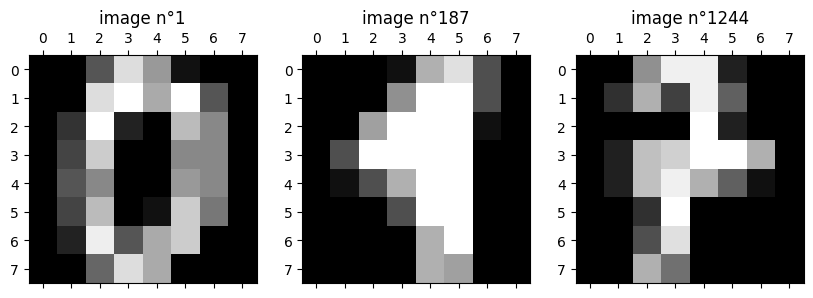

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(10, 10))
axes[0].matshow(digits.images[0])
axes[0].set_title("image n°1")
axes[1].matshow(digits.images[186])
axes[1].set_title("image n°187")
axes[2].matshow(digits.images[1243])
axes[2].set_title("image n°1244")
plt.show()

2. 

In [75]:
tab = []

for i in range(1000):

    X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3)

    NN1 = KNeighborsClassifier(n_neighbors=1)
    NN1.fit(X_train, y_train)

    k = NN1.kneighbors(X_test, return_distance=False)

    y_pred = y_train[k]

    tab.append(accuracy_score(y_pred, y_test))

# print(round(np.mean(tab), 3))
# print(round(np.var(tab), 3))

L'accuracy score de l'algorithme est de **0,987** avec une variance de **0.0**.  
C'est un algorithme tres efficace pour classer les exemple dans la base.  

## Analyse en composantes principales

1.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3)

pca = PCA()
pca.fit(X_train)

# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)

# plt.plot(pca)

PCA()

On utilise que la base d'apprentissage car c'est elle qui est en 64 dimension et que l'on veut reduire.  

2.

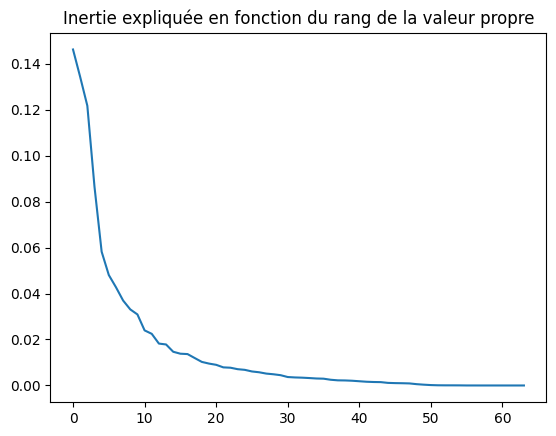

In [84]:
plt.plot(pca.explained_variance_ratio_)
plt.title("Inertie expliquée en fonction du rang de la valeur propre")
plt.show()

**Non** on ne peut pas appliquer le critere de Catell car il n'y a pas une valeur precise ou la courbe change brusquement de trajectoire.

3.

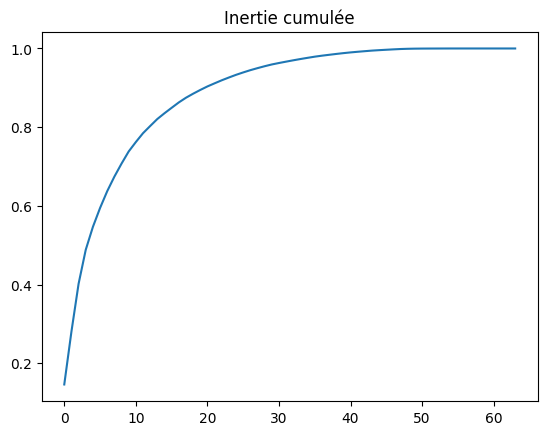

In [78]:
var_cum = np.cumsum(pca.explained_variance_ratio_)

plt.plot(var_cum)
plt.title("Inertie cumulée")
plt.show()

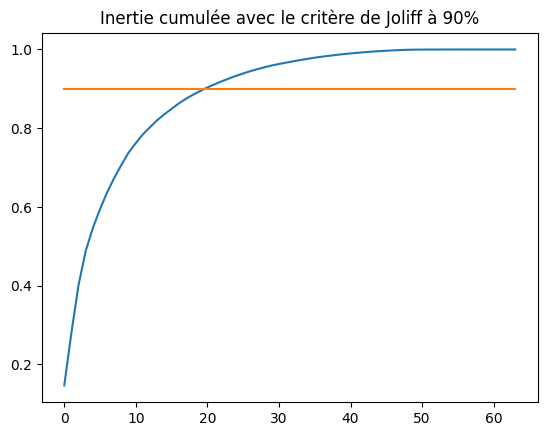

In [82]:
fig, ax = plt.subplots()

ax.plot(var_cum)
ax.plot([0.9 for _ in range(64)])
ax.set_title("Inertie cumulée avec le critère de Joliff à 90%")
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.show()

In [76]:
joliffe = 0
for u, v in enumerate(var_cum):
    if v >= 0.9:
        # print(v)
        joliffe = u
        break

# print(joliffe)


le critere de Joliffe à **90%** nous permet de trouver comme nombre optimal **20**.

## Classification

In [87]:
p2 = PCA(n_components=joliffe)
p2.fit(X_train)

x_train_red = p2.transform(X_train)
x_test_red = p2.transform(X_test)

NN1 = KNeighborsClassifier(n_neighbors=1)

NN1.fit(x_train_red, y_train)

k = NN1.kneighbors(x_test_red, return_distance=False)

y_pred = y_train[k]

# print(accuracy_score(y_pred, y_test))


Avec un nombre de composant égal à **20**, nous avons une précision d'environ **98%**.

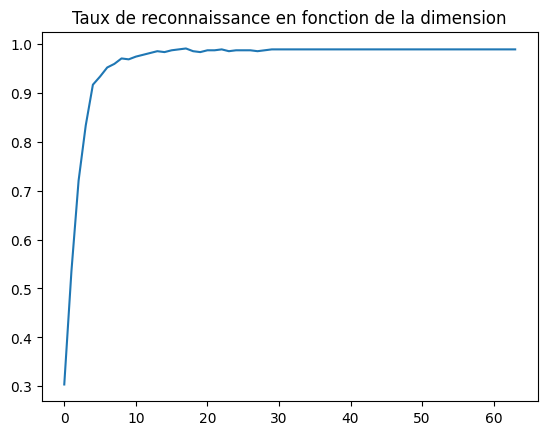

In [89]:
tab = []

for i in range(1, 65, 1):
    p2 = PCA(n_components=i)
    p2.fit(X_train)

    x1 = p2.transform(X_train)
    x2 = p2.transform(X_test)

    NN1 = KNeighborsClassifier(n_neighbors=1)

    NN1.fit(x1, y_train)

    k = NN1.kneighbors(x2, return_distance=False)

    y_pred = y_train[k]

    # print(accuracy_score(y_pred, y_test))
    tab.append(accuracy_score(y_pred, y_test))

plt.plot(tab)
plt.title("Taux de reconnaissance en fonction de la dimension")
plt.show()

On constate que le courbe atteint son maximum quand le M est égal à environ 10.

## Compression

1.

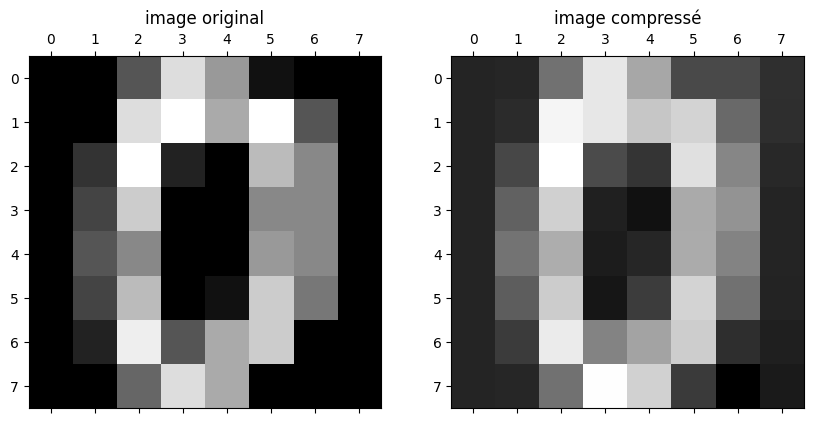

In [94]:
reduire = PCA(n_components=joliffe)
reduire.fit(data)

x_train_reduit = reduire.transform(data)

x_train_augment = reduire.inverse_transform(x_train_reduit)


fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].matshow(data[0].reshape(8, 8))
axes[0].set_title("image original")
axes[1].matshow(x_train_augment[0].reshape(8, 8))
axes[1].set_title("image compressé")
plt.show()

On remarque que les **couleurs sombres** sont **moins prononcer** mais que la **forme global** de **l'image compressé** est **identique** et **reconnaissable** face à **l'original**.

2.

In [57]:
error = np.sqrt(mean_squared_error(data, x_train_augment))

# print(error)

1.4086456807901846


L'erreur de reconstruction est d'environ **1.4**. 

3.

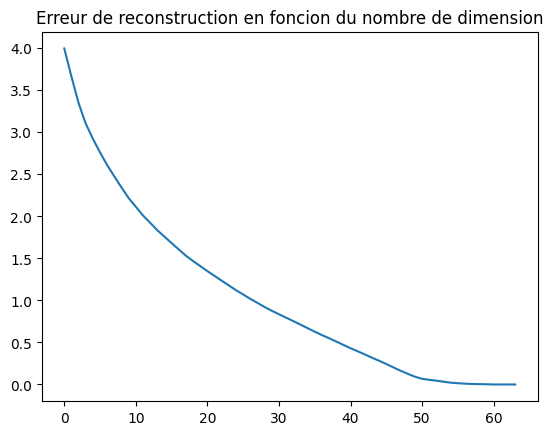

In [96]:
tab = []

for i in range(1, 65, 1):
    test = PCA(n_components=i)
    test.fit(data)

    x_train_reduit = test.transform(data)

    x_train_augment = test.inverse_transform(x_train_reduit)

    tab.append(np.sqrt(mean_squared_error(data, x_train_augment)))

plt.plot(tab)
plt.title("Erreur de reconstruction en foncion du nombre de dimension")
plt.show()
